In [1]:
import cv2
import random
import argparse

import numpy as np
from typing import List, Optional, Tuple


class OBELIX:
    def __init__(
        self,
        scaling_factor: int,
        arena_size: int = 500,
        max_steps: int = 1000,
        wall_obstacles: bool = False,
        difficulty: int = 0,
        box_speed: int = 2,
        seed: Optional[int] = None,
    ):
        self.scaling_factor = scaling_factor
        self.arena_size = arena_size
        self.frame_size = (arena_size, arena_size, 3)
        self.frame = np.ones(self.frame_size, np.uint8) * 0
        self.bot_radius = int(scaling_factor * 12 / 2)  # 12" diameter
        self.facing_angle = 0

        self.bot_center_x = 200
        self.bot_center_y = 200
        self.bot_color = (255, 255, 255)

        self.move_options = {"L45": 45, "L22": 22.5, "FW": 0, "R22": -22.5, "R45": -45}
        self.forward_step_unit = 5

        self.sonar_fov = 20
        self.sonar_far_range = 30 * scaling_factor
        self.sonar_near_range = 18 * scaling_factor
        self.sonar_range_offset = 9 * scaling_factor
        self.sonar_positions = [-90 - 22, -90 + 22, -45, -22, 22, 45, 90 - 22, 90 + 22]
        self.sonar_facing_angles = [-90, -90, 0, 0, 0, 0, 90, 90]

        self.ir_sensor_range = 4 * scaling_factor

        self.reward = 0
        self.sensor_feedback = np.zeros(18)
        # Track one-time sensor-bit rewards (per episode).
        # Indices 0..16 correspond to sensor bits; index 17 is reserved for stuck_flag.
        self._sensor_reward_claimed = np.zeros(17, dtype=bool)
        self._just_enabled_push = False
        self.sensor_feedback_masks = np.zeros(
            (9, self.frame_size[0], self.frame_size[1]), np.uint8
        )
        self.stuck_flag = 0

        self.max_steps = max_steps
        self.current_step = 0

        self.wall_obstacles = wall_obstacles
        self.obstacles: List[Tuple[Tuple[int, int], Tuple[int, int]]] = []

        # Difficulty knobs (kept simple and reproducible).
        # 0: static box
        # 2+: blinking box
        # 3+: moving box (random trajectory)
        self.difficulty = difficulty
        self.box_speed = int(box_speed)
        self.box_blink_enabled = difficulty >= 2
        self.box_move_enabled = difficulty >= 3

        self.box_visible = True
        self._blink_countdown = 0
        self._blink_on_range = (30, 60)
        self._blink_off_range = (10, 30)

        self._box_vx = 0
        self._box_vy = 0

        # Success = attach to box, then move box into a corner goal region.
        self.goal_margin = 20 * scaling_factor
        self.success_bonus = 2000

        self.rng = np.random.default_rng(seed)

        self.box_size = int(12 * scaling_factor)
        self.box_center_x = 0
        self.box_center_y = 0
        self.box_yaw_angle = 30
        self.box_corners = []
        self.box_frame = np.zeros(self.frame_size, np.uint8)

        # Negative object kept for compatibility; not used in scoring by default.
        self.neg_circle_frame = np.zeros(self.frame_size, np.uint8)
        self.neg_circle_center_x = 0
        self.neg_circle_center_y = 0

        self.obstacle_frame = np.zeros(self.frame_size, np.uint8)

        self.bot_mask = np.ones(self.frame_size, np.uint8) * 0
        self.done = False
        self.enable_push = False
        self.active_state = "F"

        self.reset(seed=seed)

    def reset(self, seed: Optional[int] = None):
        if seed is not None:
            self.rng = np.random.default_rng(seed)

        self.current_step = 0
        self.reward = 0
        self.done = False
        self.enable_push = False
        self.active_state = "F"
        self.stuck_flag = 0
        self.sensor_feedback[:] = 0
        self._sensor_reward_claimed[:] = False
        self._just_enabled_push = False

        # Build obstacles first so we can avoid spawning inside/too-close to walls.
        self._build_obstacles()

        def circle_intersects_rect(cx: int, cy: int, radius: int, rect) -> bool:
            (x1, y1), (x2, y2) = rect
            # Normalize.
            if x1 > x2:
                x1, x2 = x2, x1
            if y1 > y2:
                y1, y2 = y2, y1
            closest_x = min(max(cx, x1), x2)
            closest_y = min(max(cy, y1), y2)
            dx = cx - closest_x
            dy = cy - closest_y
            return (dx * dx + dy * dy) <= (radius * radius)

        def clear_of_obstacles(cx: int, cy: int, radius: int) -> bool:
            if not self.wall_obstacles:
                return True
            for rect in self.obstacles:
                if circle_intersects_rect(cx, cy, radius, rect):
                    return False
            return True

        # Clearance so the bot doesn't spawn "touching" a wall and immediately get stuck.
        start_clearance = max(1, int(self.forward_step_unit) + 1)

        bot_bounds_margin = 10 + self.bot_radius + start_clearance
        box_half = max(1, self.box_size // 2)
        box_bounds_margin = 10 + box_half

        max_attempts = 5000
        attempts = 0

        # Sample bot position.
        while True:
            attempts += 1
            if attempts > max_attempts:
                raise RuntimeError("Failed to sample a valid initial bot position")
            bx = int(
                self.rng.integers(
                    bot_bounds_margin, self.frame_size[1] - bot_bounds_margin
                )
            )
            by = int(
                self.rng.integers(
                    bot_bounds_margin, self.frame_size[0] - bot_bounds_margin
                )
            )
            # Use inflated radius for clearance from obstacles.
            if clear_of_obstacles(bx, by, self.bot_radius + start_clearance):
                self.bot_center_x = bx
                self.bot_center_y = by
                break

        self.facing_angle = int(self.rng.integers(0, 360))

        # Sample box position (avoid obstacles and avoid spawning already attached).
        while True:
            attempts += 1
            if attempts > max_attempts:
                raise RuntimeError("Failed to sample a valid initial box position")
            x = int(
                self.rng.integers(
                    box_bounds_margin, self.frame_size[1] - box_bounds_margin
                )
            )
            y = int(
                self.rng.integers(
                    box_bounds_margin, self.frame_size[0] - box_bounds_margin
                )
            )
            if not clear_of_obstacles(x, y, box_half):
                continue
            dx = x - self.bot_center_x
            dy = y - self.bot_center_y
            min_sep = self.bot_radius + box_half + start_clearance
            if (dx * dx + dy * dy) >= (min_sep * min_sep):
                self.box_center_x = x
                self.box_center_y = y
                break

        self.box_yaw_angle = 30

        self.box_visible = True
        self._reset_box_dynamics()

        self.neg_circle_center_x = int(
            self.rng.integers(box_bounds_margin, self.frame_size[1] - box_bounds_margin)
        )
        self.neg_circle_center_y = int(
            self.rng.integers(box_bounds_margin, self.frame_size[0] - box_bounds_margin)
        )
        self.neg_circle_frame = np.zeros(self.frame_size, np.uint8)

        self._update_frames(show=False)
        self.get_feedback()
        self.update_reward()
        return self.sensor_feedback.copy()

    def _reset_box_dynamics(self) -> None:
        # Initialize blink schedule.
        if self.box_blink_enabled:
            self.box_visible = True
            self._blink_countdown = int(
                self.rng.integers(self._blink_on_range[0], self._blink_on_range[1] + 1)
            )
        else:
            self.box_visible = True
            self._blink_countdown = 0

        # Initialize moving trajectory.
        if self.box_move_enabled:
            directions = [
                (-1, -1),
                (-1, 0),
                (-1, 1),
                (0, -1),
                (0, 1),
                (1, -1),
                (1, 0),
                (1, 1),
            ]
            dx, dy = directions[int(self.rng.integers(0, len(directions)))]
            self._box_vx = int(dx * max(1, self.box_speed))
            self._box_vy = int(dy * max(1, self.box_speed))
        else:
            self._box_vx = 0
            self._box_vy = 0

    def _update_box_dynamics(self) -> None:
        # Once attached, the box is always present and moves with the robot.
        if self.enable_push:
            self.box_visible = True
            return

        # Blinking / appearing-disappearing.
        if self.box_blink_enabled:
            self._blink_countdown -= 1
            if self._blink_countdown <= 0:
                self.box_visible = not self.box_visible
                if self.box_visible:
                    lo, hi = self._blink_on_range
                else:
                    lo, hi = self._blink_off_range
                self._blink_countdown = int(self.rng.integers(lo, hi + 1))

        # Random trajectory.
        if self.box_move_enabled:
            # Small probability of changing direction to make it less predictable.
            if float(self.rng.random()) < 0.05:
                self._reset_box_dynamics()

            next_x = int(self.box_center_x + self._box_vx)
            next_y = int(self.box_center_y + self._box_vy)
            half = max(1, self.box_size // 2)

            min_x = 10 + half
            max_x = self.frame_size[1] - 10 - half
            min_y = 10 + half
            max_y = self.frame_size[0] - 10 - half

            bounced = False
            # If it would go out of bounds, clip to boundary (episode will terminate on boundary touch).
            if not (min_x <= next_x <= max_x):
                bounced = True
            if not (min_y <= next_y <= max_y):
                bounced = True

            # Obstacle interaction: treat the box as a circle and bounce off walls.
            if self.wall_obstacles and not bounced:
                for p1, p2 in self.obstacles:
                    x1, y1 = p1
                    x2, y2 = p2
                    # Expand rectangle by half-size.
                    x1e, x2e = x1 - half, x2 + half
                    y1e, y2e = y1 - half, y2 + half
                    if (x1e <= next_x <= x2e) and (y1e <= next_y <= y2e):
                        # Simple bounce: reverse the dominant component.
                        if abs(self._box_vx) >= abs(self._box_vy):
                            self._box_vx = -self._box_vx
                        else:
                            self._box_vy = -self._box_vy
                        bounced = True
                        break

            self.box_center_x = int(np.clip(next_x, min_x, max_x))
            self.box_center_y = int(np.clip(next_y, min_y, max_y))

    def _build_obstacles(self):
        self.obstacles = []
        if not self.wall_obstacles:
            return

        # One static wall with a gap; obstacles are indistinguishable from the box (same intensity).
        wall_thickness = max(6, int(4 * self.scaling_factor))
        x_center = self.frame_size[1] // 2
        x1 = x_center - wall_thickness // 2
        x2 = x_center + wall_thickness // 2

        # Keep a guaranteed passage: bot circle + attached box clearance.
        # This avoids configurations where the wall blocks the arena.
        min_gap = 2 * (self.bot_radius + max(1, self.box_size // 2)) + max(
            10, self.forward_step_unit * 2
        )
        # If the arena is too small, skip obstacles rather than trapping the agent.
        if min_gap >= (self.frame_size[0] - 40):
            self.obstacles = []
            return

        gap_height = max(min_gap, int(12 * self.scaling_factor))
        gap_y_center = self.frame_size[0] // 2
        y_top_end = max(10, gap_y_center - gap_height // 2)
        y_bottom_start = min(self.frame_size[0] - 10, gap_y_center + gap_height // 2)

        self.obstacles.append(((x1, 10), (x2, y_top_end)))
        self.obstacles.append(((x1, y_bottom_start), (x2, self.frame_size[0] - 10)))

    def _box_would_collide(self, new_x: int, new_y: int) -> bool:
        if not self.wall_obstacles:
            return False

        half = max(1, self.box_size // 2)
        box_mask_t = np.zeros((self.frame_size[0], self.frame_size[1]), np.uint8)
        cv2.circle(box_mask_t, (new_x, new_y), half, 255, -1)

        obstacle_mask = np.zeros((self.frame_size[0], self.frame_size[1]), np.uint8)
        for p1, p2 in self.obstacles:
            cv2.rectangle(obstacle_mask, p1, p2, 255, -1)

        return np.any(
            (box_mask_t.astype(np.uint16) + obstacle_mask.astype(np.uint16)) > 255
        )

    def _box_touches_boundary(self, x: int, y: int) -> bool:
        half = max(1, self.box_size // 2)
        left = x - half
        right = x + half
        bottom = y - half
        top = y + half
        # Boundary is the inner rectangle drawn at offset=10.
        return (
            left <= 10
            or right >= (self.frame_size[1] - 10)
            or bottom <= 10
            or top >= (self.frame_size[0] - 10)
        )

    def _would_collide(self, new_x: int, new_y: int) -> bool:
        if not self.wall_obstacles:
            return False

        bot_mask_t = np.zeros((self.frame_size[0], self.frame_size[1]), np.uint8)
        cv2.circle(bot_mask_t, (new_x, new_y), self.bot_radius, 255, -1)

        obstacle_mask = np.zeros((self.frame_size[0], self.frame_size[1]), np.uint8)
        for p1, p2 in self.obstacles:
            cv2.rectangle(obstacle_mask, p1, p2, 255, -1)

        return np.any(
            (bot_mask_t.astype(np.uint16) + obstacle_mask.astype(np.uint16)) > 255
        )

    def _update_frames(self, show: bool) -> None:
        # Always build masks/frames so observation is correct in headless mode.
        self.frame = np.ones(self.frame_size, np.uint8) * 0
        self.bot_mask = np.ones(self.frame_size, np.uint8) * 0
        cv2.rectangle(
            self.frame,
            (0 + 5, 0 + 5),
            (self.frame_size[0] - 5, self.frame_size[1] - 5),
            (255, 0, 0),
            1,
        )
        cv2.rectangle(
            self.frame,
            (0 + 10, 0 + 10),
            (self.frame_size[0] - 10, self.frame_size[1] - 10),
            (255, 0, 0),
            1,
        )

        self.box_frame = np.zeros(self.frame_size, np.uint8)
        if self.box_visible or self.enable_push:
            self.box_corners = []
            for i in range(0, 360, 90):
                x = self.box_center_x + (self.box_size // 2) * np.cos(
                    np.deg2rad(self.box_yaw_angle + i)
                )
                y = self.box_center_y + (self.box_size // 2) * np.sin(
                    np.deg2rad(self.box_yaw_angle + i)
                )
                self.box_corners.append([x, y])
            cv2.fillPoly(
                self.box_frame,
                np.array([self.box_corners], dtype=np.int32),
                (100, 100, 100),
            )

        self.obstacle_frame = np.zeros(self.frame_size, np.uint8)
        for p1, p2 in self.obstacles:
            cv2.rectangle(self.obstacle_frame, p1, p2, (100, 100, 100), -1)

        self.sensor_feedback_masks = np.zeros(
            (9, self.frame_size[0], self.frame_size[1]), np.uint8
        )

        cv2.circle(
            self.frame,
            (self.bot_center_x, self.bot_center_y),
            self.bot_radius,
            self.bot_color,
            1,
        )
        cv2.circle(
            self.bot_mask,
            (self.bot_center_x, self.bot_center_y),
            self.bot_radius,
            (100, 100, 100),
            -1,
        )
        # self.bot_mask = cv2.flip(self.bot_mask, 0)
        # cv2.imshow("bot_mask", self.bot_mask)
        # cv2.imshow("box_frame", self.box_frame)

        for sonar_range, sonar_intensity in zip(
            [self.sonar_far_range, self.sonar_near_range, self.sonar_range_offset],
            [100, 50, 0],
        ):
            for index, (sonar_pos_angle, sonar_face_angle) in enumerate(
                zip(self.sonar_positions, self.sonar_facing_angles)
            ):
                if sonar_intensity == 0:
                    noise_reduction = 2
                else:
                    noise_reduction = 0
                p1_x = self.bot_center_x + self.bot_radius * np.cos(
                    np.deg2rad(self.facing_angle + sonar_pos_angle)
                )
                p1_y = self.bot_center_y + self.bot_radius * np.sin(
                    np.deg2rad(self.facing_angle + sonar_pos_angle)
                )
                p2_x = p1_x + sonar_range * np.cos(
                    np.deg2rad(
                        self.facing_angle
                        + sonar_face_angle
                        + self.sonar_fov // 2
                        + noise_reduction
                    )
                )
                p2_y = p1_y + sonar_range * np.sin(
                    np.deg2rad(
                        self.facing_angle
                        + sonar_face_angle
                        + self.sonar_fov // 2
                        + noise_reduction
                    )
                )
                p3_x = p1_x + sonar_range * np.cos(
                    np.deg2rad(
                        self.facing_angle
                        + sonar_face_angle
                        - self.sonar_fov // 2
                        - noise_reduction
                    )
                )
                p3_y = p1_y + sonar_range * np.sin(
                    np.deg2rad(
                        self.facing_angle
                        + sonar_face_angle
                        - self.sonar_fov // 2
                        - noise_reduction
                    )
                )

                cv2.fillPoly(
                    self.frame,
                    np.array(
                        [[[p1_x, p1_y], [p2_x, p2_y], [p3_x, p3_y]]], dtype=np.int32
                    ),
                    sonar_intensity,
                )
                cv2.fillPoly(
                    self.sensor_feedback_masks[index],
                    np.array(
                        [[[p1_x, p1_y], [p2_x, p2_y], [p3_x, p3_y]]], dtype=np.int32
                    ),
                    sonar_intensity,
                )

        p1_x = int(
            self.bot_center_x + self.bot_radius * np.cos(np.deg2rad(self.facing_angle))
        )
        p1_y = int(
            self.bot_center_y + self.bot_radius * np.sin(np.deg2rad(self.facing_angle))
        )
        p2_x = int(p1_x + self.ir_sensor_range * np.cos(np.deg2rad(self.facing_angle)))
        p2_y = int(p1_y + self.ir_sensor_range * np.sin(np.deg2rad(self.facing_angle)))
        cv2.line(self.frame, (p1_x, p1_y), (p2_x, p2_y), (0, 0, 255), 2)
        cv2.line(
            self.sensor_feedback_masks[8], (p1_x, p1_y), (p2_x, p2_y), (50, 50, 50), 2
        )

        self.frame = cv2.addWeighted(self.frame, 1.0, self.box_frame, 1.0, 0)
        self.frame = cv2.addWeighted(self.frame, 1.0, self.obstacle_frame, 1.0, 0)
        self.frame = cv2.addWeighted(self.frame, 1.0, self.neg_circle_frame, 1.0, 0)
        self.frame = cv2.flip(self.frame, 0)

        # feedback_image = np.asarray(self.sensor_feedback * 255, np.uint8).reshape(self.sensor_feedback.shape[0], 1).T
        # feedback_image = cv2.resize(feedback_image, (frame.shape[1], 20), cv2.INTER_NEAREST)
        # cv2.imshow("feedback_sensor_image", feedback_image)
        if show:
            cv2.imshow(
                "Experiment Environment (Behaviour 1: Finding a Box)", self.frame
            )
            cv2.waitKey(1)
        # for i in range(9):
        #     cv2.imshow("mask" + str(i), cv2.flip(self.sensor_feedback_masks[i], 0))

    def render_frame(self):
        self._update_frames(show=True)

    def update_state_diagram(self):
        state_frame = np.ones((200, 200, 3), np.uint8) * 0
        active_state_pos = {"P": (50, 50), "F": (150, 50), "U": (100, 150)}

        cv2.line(state_frame, (50, 50), (150, 50), (255, 255, 255), 1)
        cv2.line(state_frame, (150, 50), (100, 150), (255, 255, 255), 1)
        cv2.line(state_frame, (100, 150), (50, 50), (255, 255, 255), 1)

        cv2.circle(state_frame, (50, 50), 29, (0, 0, 0), -1)
        cv2.circle(state_frame, (150, 50), 29, (0, 0, 0), -1)
        cv2.circle(state_frame, (100, 150), 29, (0, 0, 0), -1)

        cv2.circle(
            state_frame, active_state_pos[self.active_state], 29, (100, 200, 0), -1
        )

        cv2.circle(state_frame, (50, 50), 30, (255, 255, 255), 1)
        cv2.putText(
            state_frame,
            "Push",
            (30, 55),
            cv2.FONT_HERSHEY_COMPLEX,
            0.5,
            (255, 255, 255),
            1,
            cv2.LINE_AA,
        )
        cv2.circle(state_frame, (150, 50), 30, (255, 255, 255), 1)
        cv2.putText(
            state_frame,
            "Find",
            (133, 55),
            cv2.FONT_HERSHEY_COMPLEX,
            0.5,
            (255, 255, 255),
            1,
            cv2.LINE_AA,
        )
        cv2.circle(state_frame, (100, 150), 30, (255, 255, 255), 1)
        cv2.putText(
            state_frame,
            "Unwedge",
            (80, 152),
            cv2.FONT_HERSHEY_COMPLEX,
            0.3,
            (255, 255, 255),
            1,
            cv2.LINE_AA,
        )

        cv2.imshow("state_frame", state_frame)

    def get_feedback(self):
        combined_object_frame = self.box_frame
        if self.wall_obstacles:
            combined_object_frame = cv2.addWeighted(
                combined_object_frame, 1.0, self.obstacle_frame, 1.0, 0
            )

        for i in range(self.sensor_feedback_masks.shape[0]):
            self.sensor_feedback[2 * i] = np.any(
                (self.sensor_feedback_masks[i] + combined_object_frame[:, :, 0]) == 150
            ) or np.any(
                (self.sensor_feedback_masks[i] + self.neg_circle_frame[:, :, 0]) == 150
            )
            self.sensor_feedback[2 * i + 1] = np.any(
                (self.sensor_feedback_masks[i] + combined_object_frame[:, :, 0]) == 200
            ) or np.any(
                (self.sensor_feedback_masks[i] + self.neg_circle_frame[:, :, 0]) == 200
            )
        self.sensor_feedback[17] = self.stuck_flag

    def step(self, move, render=True):
        if self.done:
            return self.sensor_feedback, self.reward, self.done

        self.current_step += 1
        self._just_enabled_push = False

        # Update target dynamics first (blinking/moving). If the box is attached,
        # this is a no-op and the box will move with the robot in the push logic below.
        self._update_box_dynamics()

        angle_change = self.move_options[move]
        self.facing_angle += angle_change
        self.active_state = "F"
        if angle_change == 0:
            bot_center_x_t = int(
                self.bot_center_x
                + self.forward_step_unit * np.cos(np.deg2rad(self.facing_angle))
            )
            bot_center_y_t = int(
                self.bot_center_y
                + self.forward_step_unit * np.sin(np.deg2rad(self.facing_angle))
            )
            box_center_x_t = int(
                self.box_center_x
                + self.forward_step_unit * np.cos(np.deg2rad(self.facing_angle))
            )
            box_center_y_t = int(
                self.box_center_y
                + self.forward_step_unit * np.sin(np.deg2rad(self.facing_angle))
            )
            if self.enable_push:
                # Allow box to reach the boundary (episode terminates when it touches).
                half = max(1, self.box_size // 2)
                min_x = 10 + half
                max_x = self.frame_size[1] - 10 - half
                min_y = 10 + half
                max_y = self.frame_size[0] - 10 - half

                box_center_x_next = int(np.clip(box_center_x_t, min_x, max_x))
                box_center_y_next = int(np.clip(box_center_y_t, min_y, max_y))

                bot_in_bounds = (10 + self.bot_radius) <= bot_center_x_t <= (
                    self.frame_size[1] - 10 - self.bot_radius
                ) and (10 + self.bot_radius) <= bot_center_y_t <= (
                    self.frame_size[0] - 10 - self.bot_radius
                )

                if (
                    bot_in_bounds
                    and (not self._would_collide(bot_center_x_t, bot_center_y_t))
                    and (
                        not self._box_would_collide(
                            box_center_x_next, box_center_y_next
                        )
                    )
                ):
                    self.box_center_x = box_center_x_next
                    self.box_center_y = box_center_y_next
                    self.bot_center_x = bot_center_x_t
                    self.bot_center_y = bot_center_y_t
                    self.stuck_flag = 0
                    self.active_state = "P"
                else:
                    # Bump into boundary/wall: do not terminate, just stay in place.
                    self.stuck_flag = 1
                    self.active_state = "U"

            elif (10 + self.bot_radius) <= bot_center_x_t <= (
                self.frame_size[1] - 10 - self.bot_radius
            ) and (10 + self.bot_radius) <= bot_center_y_t <= (
                self.frame_size[0] - 10 - self.bot_radius
            ):
                if not self._would_collide(bot_center_x_t, bot_center_y_t):
                    self.bot_center_x = bot_center_x_t
                    self.bot_center_y = bot_center_y_t
                    self.stuck_flag = 0
                else:
                    self.stuck_flag = 1
                    self.active_state = "U"
            else:
                self.stuck_flag = 1
                self.active_state = "U"

        self._update_frames(show=render)
        self.get_feedback()
        self.update_reward()
        self.check_done_state()
        if render:
            self.update_state_diagram()

        if (not self.done) and (self.current_step >= self.max_steps):
            self.done = True

        return self.sensor_feedback, self.reward, self.done

    def check_done_state(self):
        # cv2.imshow("added_bot_box", self.bot_mask[:, :, 0] + self.box_frame[:, :, 0])
        if (self.box_visible or self.enable_push) and np.any(
            (self.bot_mask[:, :, 0] + self.box_frame[:, :, 0]) == 200
        ):
            # Enable push on first attachment only.
            if not self.enable_push:
                self.reward += 100
                self._just_enabled_push = True
            y = (
                np.argmax((self.bot_mask[:, :, 0] + self.box_frame[:, :, 0]))
                // self.frame_size
            )[0]
            x = (
                np.argmax((self.bot_mask[:, :, 0] + self.box_frame[:, :, 0]))
                % self.frame_size
            )[0]
            # cv2.circle(self.frame, (x, int(self.frame_size[0]-y)), self.bot_radius//10, (250, 250, 250), -1)
            # cv2.imshow("asdf", self.frame)
            self.enable_push = True
            self.box_visible = True
            self.active_state = "P"

            # Per the reward table: each step in push state incurs -1.
            # Apply it immediately on the transition into push.
            if self._just_enabled_push:
                self.reward += -1

            # print("************done*********************")
        elif np.any((self.bot_mask[:, :, 0] + self.neg_circle_frame[:, :, 0]) == 200):
            self.done = True
            self.reward += -100
            print("************Negative done*********************")

        # Episode ends when the attached box touches the boundary.
        if (
            (not self.done)
            and self.enable_push
            and self._box_touches_boundary(self.box_center_x, self.box_center_y)
        ):
            self.done = True
            self.reward += self.success_bonus

        # if self.bot_center_x == self.box_center_x and self.bot_center_y==self.bot_center_y:
        #     self.done = True
        #     self.reward = 100

    def update_reward(self):
        # Base per-step reward (not cumulative).
        reward = 0.0

        # One-time sensor-bit bonuses (incurred only once per episode).
        # Bits 0..16 are sensors, bit 17 is stuck_flag.
        sensor_bits = self.sensor_feedback[:17].astype(bool)

        weights = np.zeros(17, dtype=float)
        # Left sensors (far/near) and right sensors (far/near): +1 per bit.
        weights[:4] = 1.0
        weights[12:16] = 1.0
        # Forward sensors: far bits +2, near bits +3.
        weights[4:12][::2] = 2.0
        weights[4:12][1::2] = 3.0
        # Infrared sensor bit: +5.
        weights[16] = 5.0

        newly_on = sensor_bits & (~self._sensor_reward_claimed)
        if np.any(newly_on):
            reward += float(np.sum(weights[newly_on]))
            self._sensor_reward_claimed |= sensor_bits

        # Stuck penalty (covers wall/boundary/blocked forward cases).
        if bool(self.sensor_feedback[17]):
            reward += -200.0

        reward += -1.0

        self.reward = float(reward)


In [ ]:
import random
from collections import deque
from dataclasses import dataclass
from typing import Deque

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

ACTIONS = ["L45", "L22", "FW", "R22", "R45"]

class DuelingDQN(nn.Module):
    def __init__(self, in_dim=18, n_actions=5):
        super().__init__()

        self.feature = nn.Sequential(
            nn.Linear(in_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU()
        )

        # Value stream
        self.value = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

        # Advantage stream
        self.advantage = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, n_actions)
        )

    def forward(self, x):
    # Ensure batch dimension exists
        if x.dim() == 1:
            x = x.unsqueeze(0)
    
        x = self.feature(x)
    
        v = self.value(x)              # (batch, 1)
        a = self.advantage(x)          # (batch, n_actions)
    
        # Combine streams (dueling formula)
        q = v + (a - a.mean(dim=1, keepdim=True))
        return q






In [3]:
@dataclass
class Transition:
    s: np.ndarray
    a: int
    r: float
    s2: np.ndarray
    done: bool

In [4]:
class PERReplay:
    def __init__(self, cap=100000, alpha=0.6):
        self.cap = cap
        self.alpha = alpha
        self.buf = []
        self.priorities = []
        self.pos = 0

    def add(self, transition):
        max_prio = max(self.priorities, default=1.0)

        if len(self.buf) < self.cap:
            self.buf.append(transition)
            self.priorities.append(max_prio)
        else:
            self.buf[self.pos] = transition
            self.priorities[self.pos] = max_prio
            self.pos = (self.pos + 1) % self.cap

    def sample(self, batch, beta=0.4):
        prios = np.array(self.priorities)
        probs = prios ** self.alpha
        probs /= probs.sum()

        idx = np.random.choice(len(self.buf), batch, p=probs)
        samples = [self.buf[i] for i in idx]

        # importance sampling weights
        total = len(self.buf)
        weights = (total * probs[idx]) ** (-beta)
        weights /= weights.max()

        s = np.stack([t.s for t in samples]).astype(np.float32)
        a = np.array([t.a for t in samples])
        r = np.array([t.r for t in samples])
        s2 = np.stack([t.s2 for t in samples]).astype(np.float32)
        d = np.array([t.done for t in samples]).astype(np.float32)
        
        return s, a, r, s2, d, idx, weights

    def update_priorities(self, idx, td_errors):
        for i, td in zip(idx, td_errors):
            self.priorities[i] = abs(td) + 1e-5

    def __len__(self):
        return len(self.buf)

In [5]:
def train():
    import matplotlib.pyplot as plt

    returns = []
    avg_returns = []
    losses = []
    eps_history = []
    success_history = []

    window = 50
    episodes = 500
    max_steps = 1000

    gamma = 0.99
    lr = 1e-3
    batch = 256

    replay_size = 100000
    warmup = 2000
    target_sync = 2000

    eps_start = 1.0
    eps_end = 0.05

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    q = DuelingDQN().to(device)
    tgt = DuelingDQN().to(device)
    tgt.load_state_dict(q.state_dict())

    opt = torch.optim.Adam(q.parameters(), lr=lr)
    replay = PERReplay(replay_size)

    steps = 0

    beta_start = 0.4
    beta_frames = 200000
    
    def beta_by_step(t):
        return min(1.0, beta_start + t * (1.0 - beta_start) / beta_frames)

    def eps_by_step(t):
        return eps_end + (eps_start - eps_end) * np.exp(-t / 50000)

    def moving_avg(x, w=100):
        if len(x) < w:
            return x
        return np.convolve(x, np.ones(w)/w, mode='valid')
    env = OBELIX(
            scaling_factor=5,
            arena_size=500,
            max_steps=max_steps,
            wall_obstacles=True,
            difficulty=0
        )
    for ep in range(episodes):
        s = env.reset()
        ep_ret = 0

        for _ in range(max_steps):

            eps = eps_by_step(steps)
            eps_history.append(eps)

            # Action selection
            if np.random.rand() < eps:
                a = np.random.randint(5)
            else:
                with torch.no_grad():
                    qs = q(torch.from_numpy(s).float().unsqueeze(0).to(device))
                    a = torch.argmax(qs, dim=1).item()

            s2, r, done = env.step(ACTIONS[a], render=False)

            # Reward scaling
            r_scaled = r / 100.0

            replay.add(Transition(s, a, r_scaled, s2, done))

            s = s2
            ep_ret += r
            steps += 1

            # Training
            if len(replay) > max(batch, warmup):

                beta = beta_by_step(steps)
                sb, ab, rb, s2b, db, idx, weights = replay.sample(batch, beta)

                sb = torch.from_numpy(sb).float().to(device)
                ab = torch.from_numpy(ab).long().to(device)
                rb = torch.from_numpy(rb).float().to(device)
                db = torch.from_numpy(db).float().to(device)
                s2b = torch.from_numpy(s2b).float().to(device)
                weights = torch.from_numpy(weights).float().to(device)
                 
                with torch.no_grad():
                    next_q = q(s2b)
                    next_a = torch.argmax(next_q, 1)

                    next_q_tgt = tgt(s2b)
                    next_val = next_q_tgt.gather(1, next_a.unsqueeze(1)).squeeze(1)

                    y = rb + gamma * (1 - db) * next_val

                pred = q(sb).gather(1, ab.unsqueeze(1)).squeeze(1)

                td_errors = y - pred
                loss = (weights * td_errors.pow(2)).mean()
                losses.append(loss.item())
                replay.update_priorities(idx, td_errors.detach().cpu().numpy())
                opt.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(q.parameters(), 10)
                opt.step()

                if steps % target_sync == 0:
                    tgt.load_state_dict(q.state_dict())

            if done:
                # Track success
                if env.enable_push and env._box_touches_boundary(env.box_center_x, env.box_center_y):
                    success_history.append(1)
                else:
                    success_history.append(0)
                break

        returns.append(ep_ret)

        if len(returns) >= window:
            avg_returns.append(np.mean(returns[-window:]))
        else:
            avg_returns.append(np.mean(returns))

        if ep % 50 == 0:
            avg = np.mean(returns[-50:])
            print(f"Episode {ep}, Return: {ep_ret}, Avg(50): {avg:.2f}, Eps: {eps:.3f}")

    torch.save(q.state_dict(), "weights.pth")
    print("Weights saved")

    # ================= PLOTTING ================= #

    # --- Plot 1: Returns ---
    plt.figure()
    plt.plot(returns, label="Episode Return")
    plt.plot(avg_returns, label="Moving Avg (50)", linewidth=2)
    plt.xlabel("Episode")
    plt.ylabel("Return")
    plt.title("Training Performance (D3QN)")
    plt.legend()
    plt.grid()
    plt.savefig("returns.png")
    plt.show()

    # --- Plot 2: Loss ---
    plt.figure()
    plt.plot(losses, alpha=0.3, label="Raw Loss")
    if len(losses) > 100:
        plt.plot(moving_avg(losses), label="Smoothed Loss", linewidth=2)
    plt.xlabel("Training Steps")
    plt.ylabel("Loss")
    plt.title("Loss Curve (D3QN)")
    plt.legend()
    plt.grid()
    plt.savefig("loss.png")
    plt.show()

    # --- Plot 3: Epsilon ---
    plt.figure()
    plt.plot(eps_history)
    plt.xlabel("Steps")
    plt.ylabel("Epsilon")
    plt.title("Exploration Decay")
    plt.grid()
    plt.savefig("epsilon.png")
    plt.show()

    # --- Plot 4: Success Rate ---
    plt.figure()
    success_rate = [
        np.mean(success_history[max(0, i-window):i+1])
        for i in range(len(success_history))
    ]
    plt.plot(success_rate)
    plt.xlabel("Episode")
    plt.ylabel("Success Rate")
    plt.title("Success Rate Over Time")
    plt.grid()
    plt.savefig("success.png")
    plt.show()

Episode 0, Return: -55184.0, Avg(50): -55184.00, Eps: 0.981
Episode 50, Return: -984.0, Avg(50): -14939.88, Eps: 0.398
Episode 100, Return: -973.0, Avg(50): -6275.12, Eps: 0.178
Episode 150, Return: -984.0, Avg(50): -3795.36, Eps: 0.097
Episode 200, Return: -972.0, Avg(50): -2716.78, Eps: 0.067
Episode 250, Return: -974.0, Avg(50): -8733.50, Eps: 0.056
Episode 300, Return: -986.0, Avg(50): -1104.08, Eps: 0.052
Episode 350, Return: -983.0, Avg(50): -2620.52, Eps: 0.051
Episode 400, Return: -974.0, Avg(50): -1148.26, Eps: 0.050
Episode 450, Return: -984.0, Avg(50): -2867.28, Eps: 0.050
Weights saved


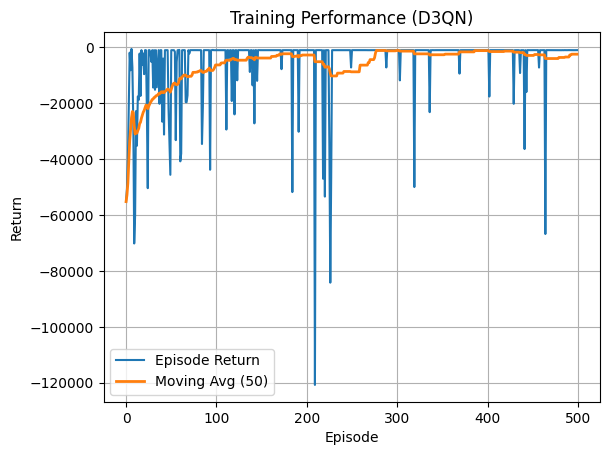

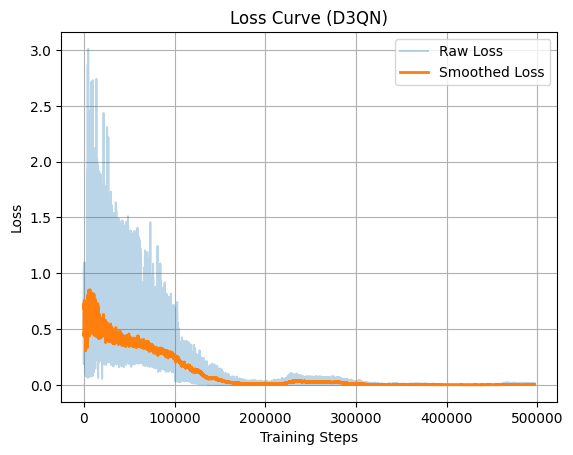

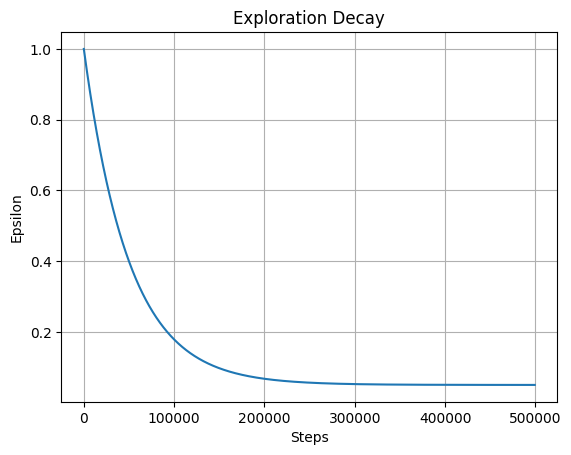

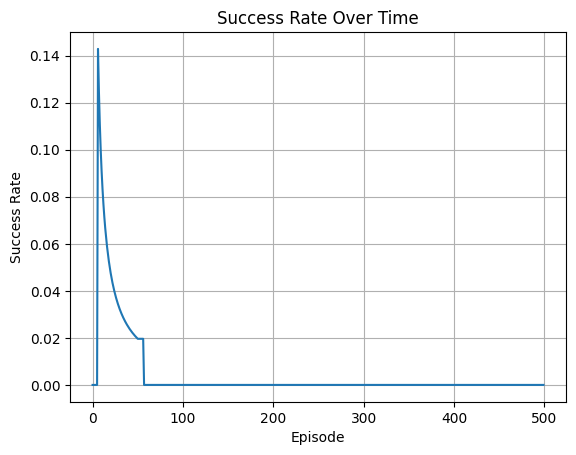

In [6]:
train()